# 03 — Mean-Reversion Strategy Tournament

## tl;dr

Fifty pre-specified mean-reversion rules were evaluated on 226 development-validation sessions. **0 strategies graduated.** The highest raw result was `moving_average_06` (Sharpe 1.55, annualized return 18.0%), but its false-discovery q-value was 0.98; it is a research lead, not established edge. The sealed holdout was not loaded.

## Context & Methods

The hypotheses follow documented contrarian and statistical-arbitrage mechanisms: short-horizon loser–winner reversal, price/residual convergence, and relative-value reversion. Key references are Lo and MacKinlay (1990), Lehmann (1990), Gatev, Goetzmann and Rouwenhorst (1999/2006), and Avellaneda and Lee (2008).

### Key assumptions

- Development data only; four fixed expanding walk-forward validation folds.
- Five instruments: CL, HG, NQ, ZN and ZT.
- Signals are delayed one session and limited to the five-session mandate.
- 10% volatility target, 2× gross ceiling and sequential drawdown controls.
- 3.5 bps cost per one-way turnover; this remains a placeholder pending broker calibration.
- Benjamini–Hochberg false-discovery control across all 50 tests.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'outputs' else Path.cwd()
PORT = ROOT / 'data/processed/portfolios'
registry = pd.read_csv(PORT / 'mean_reversion_50_registry.csv')
summary = pd.read_csv(PORT / 'mean_reversion_50_summary.csv')
folds = pd.read_csv(PORT / 'mean_reversion_50_fold_results.csv')
registry.groupby('family').size().rename('strategies').to_frame()

,strategies
family,
cross_sectional_contrarian,10
moving_average_deviation,10
range_exhaustion,10
regression_residual,10
return_reversal,10


## Data

All inputs are causal session features derived from the approved one-minute files.

In [2]:
summary.head(10)[['strategy', 'annualized_return', 'annualized_volatility', 'sharpe', 'maximum_drawdown', 'positive_folds', 'worst_fold_sharpe', 'fdr_q_value', 'graduates']]

,strategy,annualized_return,annualized_volatility,sharpe,maximum_drawdown,positive_folds,worst_fold_sharpe,fdr_q_value,graduates
0,moving_average_06,0.179788,0.116086,1.548745,-0.068981,3,-1.197214,0.97678,False
1,exhaustion_01,0.122786,0.107901,1.137953,-0.069597,3,-0.415521,0.97678,False
2,exhaustion_09,0.127148,0.117610,1.081104,-0.068181,2,-0.816857,0.97678,False
3,cross_sectional_log_return_1s_rank,0.066707,0.081270,0.820812,-0.063867,3,-1.018775,0.97678,False
4,moving_average_10,0.040319,0.057101,0.706108,-0.056152,3,-1.136856,0.97678,False
5,return_reversal_08,0.068254,0.103386,0.660192,-0.079896,3,-0.725833,0.97678,False
6,moving_average_07,0.045868,0.076016,0.603407,-0.070495,3,-2.195790,0.97678,False
7,moving_average_04,0.035691,0.060173,0.593137,-0.053434,3,-2.165440,0.97678,False
8,moving_average_09,0.067027,0.118116,0.567468,-0.078430,3,-0.785706,0.97678,False
9,cross_sectional_momentum_10s_rank,0.042156,0.097679,0.431575,-0.083932,2,-1.830209,0.97678,False


## Results

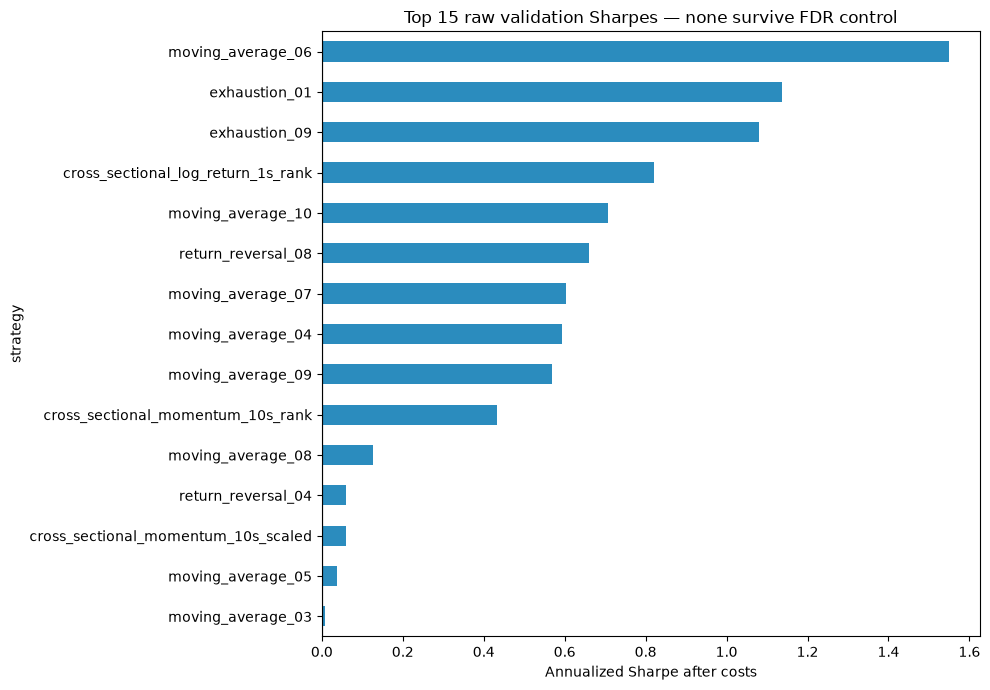

In [3]:
plot = summary.sort_values('sharpe').tail(15)
colors = ['#2b8cbe' if value >= 0 else '#d7301f' for value in plot['sharpe']]
ax = plot.plot.barh(x='strategy', y='sharpe', color=colors, legend=False, figsize=(10, 7))
ax.axvline(0, color='black', lw=.8)
ax.set_title('Top 15 raw validation Sharpes — none survive FDR control')
ax.set_xlabel('Annualized Sharpe after costs')
plt.tight_layout(); plt.show()

In [4]:
leaders = summary.head(5)['strategy']
folds[folds['strategy'].isin(leaders)].pivot(index='strategy', columns='fold', values='sharpe').round(2)

fold,1,2,3,4
strategy,,,,
cross_sectional_log_return_1s_rank,1.70,2.28,-1.02,1.71
exhaustion_01,1.54,1.91,-0.42,2.44
exhaustion_09,2.92,-0.04,1.74,-0.82
moving_average_06,3.65,-1.20,2.72,1.80
moving_average_10,2.67,-1.14,0.03,2.64


## Takeaways

1. **No validated edge yet.** Zero rules satisfy the predeclared consistency and FDR gates.
2. The 120-session moving-average deviation and close-location exhaustion rules are the best leads for economic decomposition, not candidates for holdout testing.
3. Several superficially attractive Sharpes collapse under fold inspection, demonstrating why selecting the best of 50 without correction would be misleading.
4. Next research should test whether the two leads are broad across instruments and regimes, then proceed to relative-value/pairs methods without changing the sealed holdout policy.

### Sources

- [Lo & MacKinlay — contrarian profits](https://academic.oup.com/rfs/article-abstract/3/2/175/1595488)
- [Lehmann — short-horizon reversals](https://academic.oup.com/qje/article-abstract/105/1/1/1928416)
- [Gatev et al. — pairs trading](https://www.nber.org/papers/w7032)
- [Avellaneda & Lee — statistical arbitrage](https://papers.ssrn.com/sol3/Delivery.cfm/SSRN_ID1197923_code649.pdf?abstractid=1153505)